# Лабораторна робота 1. Побудова простого лінійного бінарного класифікатора

### Дисципліна: Розпізнавання образів та комп'ютерний зір

### Група: КІ-22-1

### Студент: Савченко Андрій Олександрович

## Завдання для самостійної роботи

### 1. Імпортувати дані для навчальної вибірки згідно з індивідуальним варіантом (імпорт організувати з файлу).
### 2. Побудувати бінарний класифікатор і вивести результати бінарної класифікації на графіку.
### 3. Дати відповіді на контрольні запитання.
### 4. Відправити результати роботи у файлі lab_1_StudentLastName.ipynb до віддаленого репозиторію на GіtHub.

## Варіант індивідульного завдання

Варіант 9:
<br> x_train_9:
<br> [[16  9]
<br> [38 44]
<br> [29 14]
<br> [41 16]
<br> [50 19]
<br> [48 11]
<br> [11 43]
<br> [21 42]
<br> [41 39]
<br> [34 46]]
<br> y_train_9:
<br> [-1 -1 -1 -1  1  1 -1 -1 -1  1]

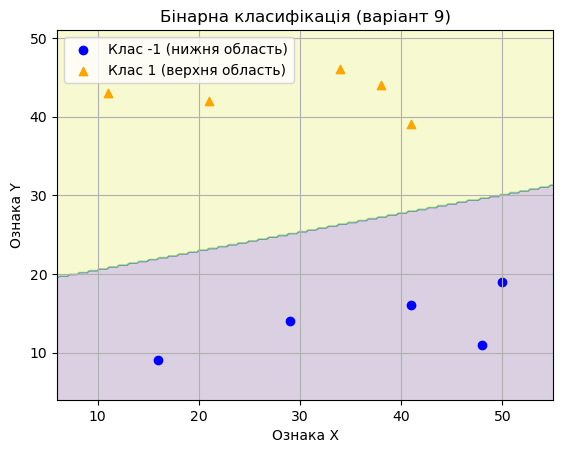

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

x_train = np.array([[16, 9],
                    [38, 44],
                    [29, 14],
                    [41, 16],
                    [50, 19],
                    [48, 11],
                    [11, 43],
                    [21, 42],
                    [41, 39],
                    [34, 46]])

y_train = np.array([-1, 1, -1, -1, -1, -1, 1, 1, 1, 1])

model = SVC(kernel='linear')
model.fit(x_train, y_train)

x_min, x_max = x_train[:, 0].min() - 5, x_train[:, 0].max() + 5
y_min, y_max = x_train[:, 1].min() - 5, x_train[:, 1].max() + 5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()

plt.contourf(xx, yy, Z, alpha=0.2)

plt.scatter(x_train[y_train == -1][:, 0],
            x_train[y_train == -1][:, 1],
            color="blue",
            marker="o",
            label="Клас -1 (нижня область)")

plt.scatter(x_train[y_train == 1][:, 0],
            x_train[y_train == 1][:, 1],
            color="orange",
            marker="^",
            label="Клас 1 (верхня область)")

plt.title("Бінарна класифікація (варіант 9)")
plt.xlabel("Ознака X")
plt.ylabel("Ознака Y")

plt.legend()
plt.grid(True)

plt.show()

## Контрольні питання

### 1. Які основні принципи лежать в основі розпізнавання образів у контексті машинного навчання?
Основні принципи розпізнавання образів у машинному навчанні:
- Представлення об’єктів у вигляді ознак - кожен об’єкт описується набором числових характеристик (вектором ознак);
- Навчання на прикладах - модель навчається на наборі даних, де відомі правильні відповіді;
- Побудова моделі класифікації - алгоритм знаходить правило, яке дозволяє віднести новий об’єкт до певного класу;
- Узагальнення - модель повинна правильно працювати не лише на навчальних даних, але і на нових;
- Мінімізація помилки - під час навчання оптимізується функція втрат.
### 2. Що таке навчальна вибірка і чому вона важлива для процесу розпізнавання образів?
Навчальна вибірка - це набір даних, який складається з об’єктів та їх правильних класів.
<br> $ (x_i,y_i),i=1..N $
<br> Вона важлива тому що:
- Використовується для навчання моделі;
- Дозволяє знайти параметри класифікатора;
- Визначає якість роботи алгоритму.
### 3. Зформулювати постановку задачі бінарної класифікації.
У задачі бінарної класифікації всі об’єкти належать до двох класів.
<br> Навчальна вибірка: $ (x_1,y_1),(x_2,y_2),...,(x_n,y_n) $
<br> де $ y_i∈{−1,+1} $
<br> Потрібно знайти функцію класифікації $ a(x) $ яка для нового об’єкта.
<br> Мета - мінімізувати кількість помилок класифікації.
### 4. Що таке рівняння гіперплощини і як воно використовується для розв’язання задачі бінарної класифікації?
Гіперплощина - це поверхня, яка розділяє простір ознак на дві частини. Її рівняння:
<br> $ w^Tx+b=0 $
<br> Класифікація виконується так: $ a(x)=sign(w^T x+b) $
<br> якщо > 0 → клас +1
<br> якщо < 0 → клас +1
### 5. Наведіть кроки для розв’язання простої задачі бінарної класифікації за допомогою машинного навчання.
1) Збір даних
2) Представлення даних у вигляді ознак
3) Вибір моделі класифікації
4) Навчання моделі
5) Оптимізація функції втрат
6) Оцінка якості моделі
7) Класифікація нових об’єктів